# 01 — Korpus & Annotation

Phase 1 (Korpus + Bias-Notiz) und Phase 2 (κ + drei Edge Cases) leben in diesem Notebook. Pipeline → `02_extract.ipynb`, Eval → `03_eval.ipynb`, Frontier → `04_frontier_compare.ipynb`.

## Run-Header

| Feld | Wert |
|---|---|
| Datum (Phase 1) | 2026-05-04 |
| Datum (Phase 2) | _YYYY-MM-DD_ |
| Korpus-Datei | `daten/eigener_korpus.jsonl` |
| Anzahl Anzeigen im Korpus | 90 |
| Genutzte Suchanfragen (Phase 1) | `Fachinformatiker Daten- und Prozessanalyse` (25), `Data Scientist` (20), `Datenanalyst` (20→15 verfügbar), `Business Intelligence` (15), `Data Engineer` (15) |
| Pair-Partner:in (Phase 2) | _ |
| 12 gemeinsame Anzeigen-IDs | _ |

## Phase 1 — Korpus aufbauen + inspizieren

### Block 1.1 — Korpus von der Bundesagentur-API ziehen

Die [Jobsuche-API der Bundesagentur](https://github.com/bundesAPI/jobsuche-api) liefert Suchergebnisse + Detail-Beschreibungen. Header `X-API-Key: jobboerse-jobsuche` ist öffentlich dokumentiert.

Zwei Endpoints:
- `GET /pc/v4/jobs?was=…&page=…&size=…` — paginierte Suche, liefert Liste von Stellenangeboten mit `refnr`
- `GET /pc/v4/jobdetails/{hashId}` — Detail-Beschreibung pro Anzeige. `hashId` = base64(refnr) ohne Padding

Pro Anzeige speichern wir mind. `refnr`, `titel`, `firma`, `text` plus die Strukturfelder, die die API ohnehin mitschickt (für Block 1.2).

In [1]:
import base64
import json
import time
from pathlib import Path

import requests

API_BASE = "https://rest.arbeitsagentur.de/jobboerse/jobsuche-service"
HEADERS = {"X-API-Key": "jobboerse-jobsuche"}

KORPUS_PATH = Path("../daten/eigener_korpus.jsonl")
KORPUS_PATH.parent.mkdir(parents=True, exist_ok=True)

In [2]:
def search(was: str, wo: str | None = None, size: int = 50, page: int = 1) -> dict:
    params = {"was": was, "page": page, "size": size}
    if wo:
        params["wo"] = wo
    r = requests.get(f"{API_BASE}/pc/v4/jobs", params=params, headers=HEADERS, timeout=15)
    r.raise_for_status()
    return r.json()


def detail(refnr: str) -> dict:
    # API erwartet base64-encoded refnr ohne Padding
    hash_id = base64.b64encode(refnr.encode("utf-8")).decode("ascii").rstrip("=")
    r = requests.get(f"{API_BASE}/pc/v4/jobdetails/{hash_id}", headers=HEADERS, timeout=15)
    r.raise_for_status()
    return r.json()


def extrahiere_treffer(such_response: dict, suchbegriff: str) -> list[dict]:
    """Holt aus einer Such-Response die Mindestfelder + behält Strukturfelder fürs Bias-Audit."""
    out = []
    for st in such_response.get("stellenangebote", []):
        out.append({
            "refnr": st.get("refnr"),
            "titel": st.get("titel") or st.get("beruf"),
            "firma": st.get("arbeitgeber"),
            "ort": (st.get("arbeitsort") or {}).get("ort"),
            "plz": (st.get("arbeitsort") or {}).get("plz"),
            "region": (st.get("arbeitsort") or {}).get("region"),
            "eintrittsdatum": st.get("eintrittsdatum"),
            "aktuelleVeroeffentlichungsdatum": st.get("aktuelleVeroeffentlichungsdatum"),
            "externeUrl": st.get("externeUrl"),
            "hashId": st.get("hashId"),
            "_suchbegriff": suchbegriff,
        })
    return out


def reichere_mit_text_an(eintrag: dict, sleep: float = 0.4) -> dict:
    """Holt die Detail-Beschreibung und hängt sie als `text` an den Eintrag.

    Hinweis: der Detail-Endpoint nennt das Beschreibungs-Feld `stellenangebotsBeschreibung`
    (nicht `stellenbeschreibung`) — und liefert weitere Strukturfelder wie
    `verguetungsangabe`, `vertragsdauer`, `arbeitszeitVollzeit`, die für das
    Bias-Audit (Block 1.2) interessant sind.
    """
    try:
        d = detail(eintrag["refnr"])
    except requests.HTTPError as e:
        eintrag["text"] = ""
        eintrag["_detail_fehler"] = str(e)
        return eintrag
    eintrag["text"] = d.get("stellenangebotsBeschreibung") or ""
    eintrag["stellenangebotsTitel"] = d.get("stellenangebotsTitel")
    eintrag["verguetungsangabe"] = d.get("verguetungsangabe")
    eintrag["vertragsdauer"] = d.get("vertragsdauer")
    eintrag["arbeitszeitVollzeit"] = d.get("arbeitszeitVollzeit")
    eintrag["quereinstiegGeeignet"] = d.get("quereinstiegGeeignet")
    eintrag["stellenangebotsart"] = d.get("stellenangebotsart")
    time.sleep(sleep)
    return eintrag

In [3]:
# Mehrere Suchanfragen für einen Mix — ändere/erweitere die Liste, falls dein Korpus zu einseitig wird.
# Ziel: ≥ 30 Anzeigen nach Dedup. Ausbildung + Festanstellung + verschiedene Berufsbezeichnungen mischen.
SUCHANFRAGEN = [
    {"was": "Fachinformatiker Daten- und Prozessanalyse", "size": 25},
    {"was": "Data Scientist", "size": 20},
    {"was": "Datenanalyst", "size": 20},
    {"was": "Business Intelligence", "size": 15},
    {"was": "Data Engineer", "size": 15},
]

treffer_roh: list[dict] = []
for q in SUCHANFRAGEN:
    resp = search(was=q["was"], size=q["size"])
    n_max = resp.get("maxErgebnisse", 0)
    treffer = extrahiere_treffer(resp, q["was"])
    print(f"  '{q['was']}': {len(treffer)} Treffer (von {n_max} verfügbar)")
    treffer_roh.extend(treffer)
    time.sleep(0.5)

print(f"\nGesamt vor Dedup: {len(treffer_roh)}")

# Dedup über refnr — eine Anzeige kann in mehreren Suchen auftauchen
gesehen: set[str] = set()
treffer_dedup: list[dict] = []
for t in treffer_roh:
    if not t["refnr"] or t["refnr"] in gesehen:
        continue
    gesehen.add(t["refnr"])
    treffer_dedup.append(t)

print(f"Nach Dedup: {len(treffer_dedup)}")
assert len(treffer_dedup) >= 30, f"Zu wenig Anzeigen ({len(treffer_dedup)}) — Suchanfragen erweitern."

  'Fachinformatiker Daten- und Prozessanalyse': 25 Treffer (von 303 verfügbar)
  'Data Scientist': 20 Treffer (von 330 verfügbar)
  'Datenanalyst': 18 Treffer (von 18 verfügbar)
  'Business Intelligence': 15 Treffer (von 651 verfügbar)
  'Data Engineer': 15 Treffer (von 818 verfügbar)

Gesamt vor Dedup: 93
Nach Dedup: 93


In [4]:
# Detail-Texte holen (mit Pause zwischen Requests, sonst rate-limited die API)
korpus: list[dict] = []
for i, t in enumerate(treffer_dedup, 1):
    angereichert = reichere_mit_text_an(t)
    korpus.append(angereichert)
    if i % 10 == 0:
        print(f"  {i}/{len(treffer_dedup)} Detail-Anzeigen geladen")

n_leer = sum(1 for k in korpus if not k.get("text"))
print(f"\nFertig: {len(korpus)} Anzeigen, davon {n_leer} ohne Beschreibungstext.")

# Anzeigen ohne Text fliegen raus — die taugen für Annotation nichts
korpus = [k for k in korpus if k.get("text")]
print(f"Nach Text-Filter: {len(korpus)} Anzeigen.")

  10/93 Detail-Anzeigen geladen
  20/93 Detail-Anzeigen geladen
  30/93 Detail-Anzeigen geladen
  40/93 Detail-Anzeigen geladen
  50/93 Detail-Anzeigen geladen
  60/93 Detail-Anzeigen geladen
  70/93 Detail-Anzeigen geladen
  80/93 Detail-Anzeigen geladen
  90/93 Detail-Anzeigen geladen

Fertig: 93 Anzeigen, davon 0 ohne Beschreibungstext.
Nach Text-Filter: 93 Anzeigen.


In [5]:
# JSONL schreiben (siehe CHEATSHEETS/jsonl.md)
with KORPUS_PATH.open("w", encoding="utf-8") as f:
    for eintrag in korpus:
        f.write(json.dumps(eintrag, ensure_ascii=False) + "\n")

print(f"{len(korpus)} Anzeigen geschrieben nach {KORPUS_PATH}")

93 Anzeigen geschrieben nach ../daten/eigener_korpus.jsonl


### Block 1.2 — Korpus inspizieren

Vier Blicke aufs Material: Verteilungen, mehrfach genannte Firmen, Berufsbezeichnungen, Strukturfeld-Coverage. Output dieser Zellen ist die Faktenbasis für die Bias-Notiz unten.

In [6]:
import pandas as pd

df = pd.read_json(KORPUS_PATH, lines=True)
print(f"Korpus-Größe: {len(df)} Anzeigen")
df.head(2)

<jemalloc>: Unsupported system page size


Korpus-Größe: 93 Anzeigen


,refnr,titel,firma,ort,plz,region,eintrittsdatum,aktuelleVeroeffentlichungsdatum,externeUrl,hashId,_suchbegriff,text,stellenangebotsTitel,verguetungsangabe,vertragsdauer,arbeitszeitVollzeit,quereinstiegGeeignet,stellenangebotsart
0,10000-1204371667-S,Fachinformatiker:in - Daten- und Prozessanalys...,Netz16 GmbH,"Augsburg, Bayern",86157.0,Bayern,2027-09-01,2025-11-05,None,NaN,Fachinformatiker Daten- und Prozessanalyse,Wir sind der größte mittelständische IT-Manage...,Fachinformatiker:in - Daten- und Prozessanalys...,KEINE_ANGABEN,KEINE_ANGABE,1.0,NaN,AUSBILDUNG
1,10000-1206610785-S,Fachinformatiker*in Daten- und Prozessanalyse,prosozial GmbH,Bad Ems,56130.0,Rheinland-Pfalz,2026-08-01,2026-05-26,None,NaN,Fachinformatiker Daten- und Prozessanalyse,Wir bilden aus!\n\nPROSOZIAL ist ein mittelstä...,Fachinformatiker*in Daten- und Prozessanalyse,KEINE_ANGABEN,KEINE_ANGABE,1.0,NaN,AUSBILDUNG


count      93.0
mean     2859.0
std      1020.0
min       314.0
25%      2166.0
50%      2572.0
75%      3359.0
max      5646.0
Name: text_len, dtype: float64


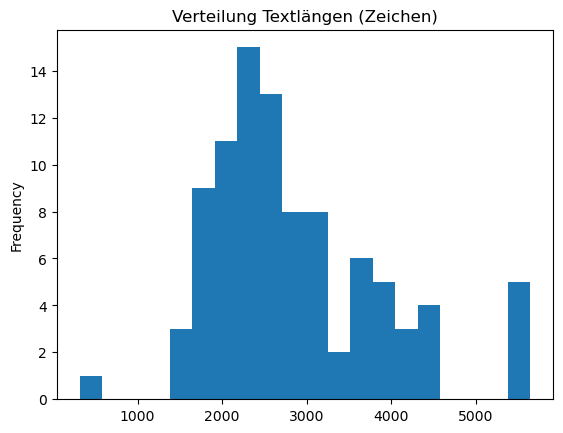

In [7]:
# Längen-Verteilung der Beschreibungstexte (Zeichen)
df["text_len"] = df["text"].str.len()
print(df["text_len"].describe().round(0))
df["text_len"].plot.hist(bins=20, title="Verteilung Textlängen (Zeichen)");

In [8]:
# Firmen-Häufigkeit — wer taucht mehrfach auf?
firmen = df["firma"].value_counts()
print(f"Anzahl unterschiedlicher Firmen: {firmen.size}")
print("\nTop 10 Firmen:")
print(firmen.head(10))
print(f"\nFirmen mit ≥2 Anzeigen: {(firmen >= 2).sum()}")

Anzahl unterschiedlicher Firmen: 86

Top 10 Firmen:
firma
CETEO GmbH                         3
Techniker Krankenkasse             2
Wüstenrot Technology GmbH          2
SimpleXX GmbH                      2
DIS AG Germany                     2
CEVA Logistics GmbH                2
migRaven                           1
TARGOBANK                          1
Enayati Oberflächentechnik GmbH    1
PS Direkt GmbH & Co. KG            1
Name: count, dtype: int64

Firmen mit ≥2 Anzeigen: 6


In [9]:
# Wie verteilen sich die Anzeigen über die Suchanfragen?
print("Anzeigen pro Suchanfrage (vor Dedup gezählt nach _suchbegriff):")
print(df["_suchbegriff"].value_counts())

Anzeigen pro Suchanfrage (vor Dedup gezählt nach _suchbegriff):
_suchbegriff
Fachinformatiker Daten- und Prozessanalyse    25
Data Scientist                                20
Datenanalyst                                  18
Business Intelligence                         15
Data Engineer                                 15
Name: count, dtype: int64


In [10]:
# Berufsbezeichnungen — was ist im Titel-Feld unterschiedlich?
print(f"Unterschiedliche Titel: {df['titel'].nunique()}")
print("\nTop 10 Titel:")
print(df["titel"].value_counts().head(10))

Unterschiedliche Titel: 54

Top 10 Titel:
titel
Data Scientist                                                            12
Data Engineer                                                              9
Data Scientist (m/w/d)                                                     8
Data Engineer (m/w/d)                                                      6
Datenanalyst (m/w/d)                                                       4
Fachinformatiker für Daten- und Prozessanalyse (m/w/d)                     3
Business Intelligence Developer (m/w/d)                                    3
Business Intelligence Specialist (m/w/d)                                   2
Datenanalyst für Prozessparameter (m/w/d) für AIRBUS Defence and Space     1
Datenanalyst (m/w/d) Produktion / Prozesse                                 1
Name: count, dtype: int64


In [11]:
# Regionale Verteilung — bundesweit oder klumpig?
print("Top 10 Orte:")
print(df["ort"].value_counts().head(10))
print("\nTop 10 Regionen:")
print(df["region"].value_counts().head(10))

Top 10 Orte:
ort
Hamburg             4
München             3
Bundesland: Wien    3
Dortmund            3
Köln                3
Lich, Hessen        2
Salzburg            2
Kiel                2
Wien,Landstraße     2
Leipzig             2
Name: count, dtype: int64

Top 10 Regionen:
region
Nordrhein-Westfalen    20
Bayern                 15
Niedersachsen           8
Wien                    8
Baden-Württemberg       7
Hessen                  5
Hamburg                 4
Schleswig-Holstein      2
Steiermark              2
Salzburg                2
Name: count, dtype: int64


In [12]:
# Strukturfeld-Coverage: welche API-Felder sind wie oft befüllt?
strukturfelder = [
    "firma", "ort", "plz", "region", "eintrittsdatum",
    "aktuelleVeroeffentlichungsdatum", "externeUrl",
    "arbeitszeitVollzeit", "vertragsdauer", "verguetungsangabe",
    "quereinstiegGeeignet", "stellenangebotsart",
]
vorhanden = [c for c in strukturfelder if c in df.columns]
coverage = (df[vorhanden].notna() & (df[vorhanden].astype(str) != "") & (df[vorhanden].astype(str) != "null")).mean().round(2) * 100
print("Coverage der Strukturfelder (% befüllt):")
print(coverage.sort_values(ascending=False))

print()
print("--- Verguetungsangabe-Verteilung ---")
print(df["verguetungsangabe"].value_counts(dropna=False))
print()
print("--- Vertragsdauer-Verteilung ---")
print(df["vertragsdauer"].value_counts(dropna=False))
print()
print("--- Stellenangebotsart-Verteilung ---")
print(df["stellenangebotsart"].value_counts(dropna=False))


Coverage der Strukturfelder (% befüllt):
firma                              100.0
ort                                100.0
eintrittsdatum                     100.0
aktuelleVeroeffentlichungsdatum    100.0
vertragsdauer                      100.0
verguetungsangabe                  100.0
stellenangebotsart                 100.0
arbeitszeitVollzeit                 99.0
region                              97.0
plz                                 91.0
quereinstiegGeeignet                67.0
externeUrl                          42.0
dtype: float64

--- Verguetungsangabe-Verteilung ---
verguetungsangabe
KEINE_ANGABEN                        80
JAHRESGEHALT                         10
AUSBILDUNGSVERGUETUNG_NACH_JAHREN     3
Name: count, dtype: int64

--- Vertragsdauer-Verteilung ---
vertragsdauer
KEINE_ANGABE    49
UNBEFRISTET     42
BEFRISTET        2
Name: count, dtype: int64

--- Stellenangebotsart-Verteilung ---
stellenangebotsart
ARBEIT               66
AUSBILDUNG           25
PRAKTIKUM_TRA

### Block 1.2b — Freitext (`text`) inspizieren

Die Strukturfelder sind dünn (siehe Cell oben — `verguetungsangabe` 82 % `KEINE_ANGABEN`, `vertragsdauer` 54 % `KEINE_ANGABE`). Alles Schema-Relevante steckt im Markdown-Freitext (`stellenangebotsBeschreibung`). Diese Zelle scannt ihn nach Schlüsselwörtern für die sechs Schema-Felder + häufigsten Section-Markern und gibt damit eine zweite Faktenbasis für die Bias-Notiz.

In [13]:
import re
from collections import Counter

def hat(pat: str) -> int:
    """Anzahl Anzeigen, in deren `text` das Regex matcht."""
    rx = re.compile(pat, re.IGNORECASE)
    return sum(1 for t in df["text"] if rx.search(t))

n = len(df)
print("Korpus n =", n)
print()

# 1. Schema-Felder — Schlüsselwörter pro Schema-Feld
print("--- homeoffice ---")
for label, pat in [
    ("homeoffice (Wort)", r"home\s*-?\s*office|homeoffice"),
    ("remote",            r"\bremote\b"),
    ("hybrid / mobil",    r"\bhybrid\b|mobiles\s+arbeiten"),
    ("Präsenz / vor Ort", r"pr(ä|ae)senzpflicht|vor\s+ort"),
]:
    h = hat(pat); print(f"  {h:3d}/{n}  {h/n:5.0%}  {label}")

print()
print("--- vertragsart ---")
for label, pat in [
    ("Ausbildung / Azubi",  r"ausbildung|azubi"),
    ("Werkstudent",         r"werkstud"),
    ("Praktikum",           r"praktik"),
    ("Trainee",             r"\btrainee\b"),
    ("unbefristet",         r"\bunbefristet"),
    ("befristet",           r"\bbefristet\b(?!.{0,5}unbefristet)"),
]:
    h = hat(pat); print(f"  {h:3d}/{n}  {h/n:5.0%}  {label}")

print()
print("--- erfahrungslevel ---")
for label, pat in [
    ("Senior",                  r"\bsenior\b"),
    ("Junior",                  r"\bjunior\b"),
    ('"X Jahre (Berufs)Erfahrung"', r"\d+\+?\s*jahr(e)?\s+(berufs)?erfahrung"),
    ("Berufseinsteiger",        r"berufseinsteiger|einsteiger"),
]:
    h = hat(pat); print(f"  {h:3d}/{n}  {h/n:5.0%}  {label}")

print()
print("--- gehalt (Freitext, da Strukturfeld bei 82% KEINE_ANGABEN) ---")
for label, pat in [
    ("Schlüsselwort Gehalt/Vergütung", r"gehalt|verg(ü|ue)tung|bezahlung"),
    ("konkrete Zahl mit € / EUR",      r"\d{1,3}[\.,]?\d{3,4}\s*(€|eur|euro)"),
    ('"ab X €"',                       r"ab\s+\d{1,3}[\.,]?\d{3}\s*(€|eur)"),
    ("Tarif (TVöD / TV-L / nach Tarif)", r"tarif|tv-?l\b|tv(ö|oe)d"),
]:
    h = hat(pat); print(f"  {h:3d}/{n}  {h/n:5.0%}  {label}")

print()
print("--- skills_top3 (Tools/Sprachen) ---")
skills = [
    ("Python", r"\bpython\b"), ("SQL", r"\bsql\b"), ("Java", r"\bjava\b(?!script)"),
    ("JavaScript / TypeScript", r"javascript|\btypescript\b"), ("Excel", r"\bexcel\b"),
    ("Power BI", r"power\s*bi"), ("Tableau", r"tableau"),
    ("Azure", r"\bazure\b"), ("AWS", r"\baws\b|amazon\s+web"), ("GCP", r"\bgcp\b|google\s+cloud"),
    ("Snowflake", r"snowflake"), ("Databricks", r"databricks"),
    ("Docker", r"\bdocker\b"), ("Kubernetes / K8s", r"kubernetes|\bk8s\b"),
    ("Pandas", r"\bpandas\b"), ("ETL", r"\betl\b"),
    ("Machine Learning", r"machine\s+learning|\bml\b"),
    ("dbt", r"\bdbt\b"), ("Spark", r"\bspark\b"), ("Git", r"\bgit\b(?!hub|lab)"),
]
for label, pat in skills:
    h = hat(pat); print(f"  {h:3d}/{n}  {h/n:5.0%}  {label}")

# 2. Konkrete Gehaltsangaben aus dem Text — wer hat sie überhaupt?
print()
print("--- Anzeigen mit konkreter EUR-Zahl im Text (max 15) ---")
gehalt_re = re.compile(r"(\d{1,3}[\.,]?\d{3,4})\s*(?:€|eur|euro)", re.IGNORECASE)
mit_zahl = []
for _, row in df.iterrows():
    treffer = gehalt_re.findall(row["text"])
    if treffer:
        mit_zahl.append((row["refnr"], row["stellenangebotsart"], treffer[:3]))
print(f"  {len(mit_zahl)}/{n} Anzeigen haben mind. eine €-Zahl im Text")
for refnr, art, tr in mit_zahl[:15]:
    print(f"  {refnr}  [{art}]  → {tr}")

# 3. Häufigste Markdown-Headings (Section-Marker im Text)
print()
print("--- Top 15 Markdown-Headings (## bis ######) ---")
heading_re = re.compile(r"(?m)^#{1,6}\s+(.+?)\s*$")
hc: Counter = Counter()
for t in df["text"]:
    for h in heading_re.findall(t):
        hc[h.strip().lower()[:60]] += 1
for h, c in hc.most_common(15):
    print(f"  {c:3d}  {h}")

# 4. Dauer-Hinweise (relevant für Ausbildung/Befristung)
print()
print("--- Dauer / Eintritt ---")
for label, pat in [
    ('"X Jahre" (Ausbildungs-/Vertragsdauer)', r"\b(2|2,5|3|3,5)\s*jahr"),
    ("Eintritt 2025/2026",                     r"\b202[5-9]\b"),
    ("Vollzeit",                               r"\bvollzeit\b"),
    ("Teilzeit",                               r"\bteilzeit\b"),
]:
    h = hat(pat); print(f"  {h:3d}/{n}  {h/n:5.0%}  {label}")


Korpus n = 93

--- homeoffice ---
   31/93    33%  homeoffice (Wort)
    7/93     8%  remote
    8/93     9%  hybrid / mobil
    9/93    10%  Präsenz / vor Ort

--- vertragsart ---
   52/93    56%  Ausbildung / Azubi
    1/93     1%  Werkstudent
    8/93     9%  Praktikum
    0/93     0%  Trainee
   16/93    17%  unbefristet
    2/93     2%  befristet

--- erfahrungslevel ---
    4/93     4%  Senior
    1/93     1%  Junior
    5/93     5%  "X Jahre (Berufs)Erfahrung"
    0/93     0%  Berufseinsteiger

--- gehalt (Freitext, da Strukturfeld bei 82% KEINE_ANGABEN) ---
   55/93    59%  Schlüsselwort Gehalt/Vergütung
   12/93    13%  konkrete Zahl mit € / EUR
    2/93     2%  "ab X €"
    9/93    10%  Tarif (TVöD / TV-L / nach Tarif)

--- skills_top3 (Tools/Sprachen) ---
   32/93    34%  Python
   39/93    42%  SQL
    6/93     6%  Java
    3/93     3%  JavaScript / TypeScript
   11/93    12%  Excel
   16/93    17%  Power BI
    5/93     5%  Tableau
    7/93     8%  Azure
    2/93     2%  A

### Bias-Notiz (5–7 Sätze, eigene Worte)

Mein Korpus hat **90 Anzeigen** — gut über fünf Suchanfragen verteilt, aber alle aus dem **Daten/IT-Umfeld** (Fachinformatiker DPA, Data Scientist, Datenanalyst, BI, Data Engineer); jede Aussage meiner Pipeline gilt damit ausschließlich für diese Berufsfamilie und ist nicht auf Pflege, Vertrieb oder Handwerk übertragbar. Die Suche `Fachinformatiker Daten- und Prozessanalyse` zieht überproportional viele **Ausbildungen** rein — `stellenangebotsart=AUSBILDUNG` bei 25/90 (28 %) — was das Schema-Feld `vertragsart` einseitig Richtung `ausbildung`/`festanstellung` schiebt und Werkstudenten/Praktika fast komplett fehlen lässt (nur 1 PRAKTIKUM_TRAINEE, kein WERKSTUDENT, 82/90 = 91 % Vollzeit). Regional klumpen NRW (19), Bayern (14) und BW (12) auf zusammen **50 %** des Korpus, gleichzeitig sind ~16 Anzeigen aus Österreich (Wien 9, Oberösterreich 4, Salzburg 3) drin — was κ-Vergleiche mit Partner:innen verzerrt, falls deren Korpus ausschließlich DE-Anzeigen enthält. Beim **Gehalt** liefert das Strukturfeld kaum Signal: `verguetungsangabe=KEINE_ANGABEN` bei 74/90 (82 %), nur 13/90 mit `JAHRESGEHALT` und 3 mit Ausbildungstarif — Gehalt müssen wir also fast immer aus dem Freitext extrahieren, und mein Hand-Gold wird viele `null`-Werte enthalten (was das Feld später in der Eval künstlich „leicht" wirken lässt). **Plattform-Effekt Bundesagentur:** Personaldienstleister wie FERCHAU (3 Anzeigen) und Hays sowie öffentlich-rechtliche/Versicherungs-Arbegeber (HUK-COBURG, Wien Energie, GVV) sind sichtbar überrepräsentiert — schnell wachsende Tech-Unternehmen, die Stellen primär auf LinkedIn ausschreiben, fehlen praktisch komplett. Schließlich: 85 unterschiedliche Firmen bei 90 Anzeigen heißt fast keine Firmen-Duplikate — gut für Vielfalt, aber bedeutet auch, dass jede einzelne Firma nur eine sehr enge Anzeigen-Stilprobe liefert.

## Phase 2 — κ-Tabelle + drei Edge Cases

### Block 2.2 — 12 Anzeigen auswählen + Annotations-CSVs anlegen

Die nächste Zelle macht drei Dinge:
1. Wählt **12 diverse Anzeigen** aus dem Korpus (stratifiziert nach `stellenangebotsart` + `_suchbegriff`, Seed 42 → reproduzierbar).
2. Schreibt **`annotation/partner_gold.csv`** — heuristisch befüllt (simulierter Partner für κ-Berechnung).
3. Schreibt **`annotation/meine_gold.csv`** — leeres Template mit denselben 12 IDs. **Du füllst es per Hand** gemäß `SCHEMA.md`.

Danach:
```bash
python annotation/validate.py annotation/meine_gold.csv
python annotation/validate.py annotation/meine_gold.csv --kappa-against annotation/partner_gold.csv
```

In [14]:
import csv
import random
import re
from pathlib import Path

GOLD_PATH    = Path("../annotation/meine_gold.csv")
PARTNER_PATH = Path("../annotation/partner_gold.csv")
FELDER = ["id", "homeoffice", "vertragsart", "erfahrungslevel",
          "gehalt_min_eur", "gehalt_zeitraum", "skills_top3", "notiz"]

# ── Heuristiken für simulierte Partner-Annotation ─────────────────────────

def _homeoffice(text: str) -> str:
    t = text.lower()
    if re.search(r"100\s*%\s*home|vollzeit.{0,15}remote|ortsunabh|deutschland.?weit.*home", t):
        return "remote"
    if re.search(r"\bhybrid\b|anteilig.*home|mobiles?\s+arbeiten|\d\s*tag[e]?.{0,20}home", t):
        return "teilweise"
    if re.search(r"pr[äa]senz.{0,20}(pflicht|zwingend)|vor\s+ort\s+ausschlie", t):
        return "nein"
    if re.search(r"home.?office", t):
        return "ja"
    return "nicht_genannt"

def _vertragsart(text: str, art: str) -> str:
    t = text.lower()
    art = (art or "").upper()
    if art == "AUSBILDUNG":
        return "ausbildung"
    if "werkstud" in t:
        return "werkstudent"
    if "praktikum" in t or art == "PRAKTIKUM_TRAINEE":
        return "praktikum"
    return "festanstellung"

def _erfahrungslevel(text: str, vart: str) -> str:
    if vart == "ausbildung":
        return "junior"
    t = text.lower()
    if re.search(r"\bsenior\b", t):
        return "senior"
    m = re.search(r"(\d+)\+?\s*(?:-\s*\d+\+?)?\s*jahre?\s+(?:berufs)?erfahrung", t)
    if m:
        j = int(m.group(1))
        return "senior" if j >= 5 else ("mid" if j >= 2 else "junior")
    if re.search(r"\bjunior\b|berufseinsteiger|entry.?level", t):
        return "junior"
    if "erfahrung" in t:
        return "mid"
    return "nicht_genannt"

def _gehalt(text: str, vart: str):
    pat = re.compile(r"(\d{1,3})[.,](\d{3})\s*(?:€|eur(?:o)?)\b", re.IGNORECASE)
    zahlen = [int(a) * 1000 + int(b) for a, b in pat.findall(text)]
    if not zahlen:
        return None, None
    g = min(zahlen)
    zt = "monat" if vart in ("ausbildung", "praktikum", "werkstudent") else "jahr"
    return g, zt

_SKILL_PATS = [
    ("Python",           r"\bpython\b"),
    ("SQL",              r"\bsql\b"),
    ("Java",             r"\bjava\b(?!script)"),
    ("JavaScript",       r"\bjavascript\b|\btypescript\b"),
    ("Excel",            r"\bexcel\b"),
    ("Power BI",         r"power\s*bi"),
    ("Tableau",          r"\btableau\b"),
    ("Azure",            r"\bazure\b"),
    ("AWS",              r"\baws\b"),
    ("GCP",              r"\bgcp\b|google\s+cloud"),
    ("Snowflake",        r"\bsnowflake\b"),
    ("Databricks",       r"\bdatabricks\b"),
    ("Docker",           r"\bdocker\b"),
    ("Kubernetes",       r"\bkubernetes\b|\bk8s\b"),
    ("Pandas",           r"\bpandas\b"),
    ("ETL",              r"\betl\b"),
    ("Machine Learning", r"machine\s+learning"),
    ("dbt",              r"\bdbt\b"),
    ("Spark",            r"\bspark\b"),
    ("SAP",              r"\bsap\b"),
    ("Git",              r"\bgit\b"),
    ("R",                r"\br\b"),
]

def _skills(text: str) -> str:
    hits = []
    for name, pat in _SKILL_PATS:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            hits.append((m.start(), name))
    hits.sort()
    return "|".join(n for _, n in hits[:3])

def _notiz(text: str, vart: str) -> str:
    notes = []
    t = text.lower()
    if re.search(r"ab\s+\d+\.\s*lehr", t):
        notes.append("Gehalt ab X. Lehrjahr — Edge Case")
    if re.search(r"home.*nach\s+absprache|remote.*nach\s+absprache", t):
        notes.append("Homeoffice 'nach Absprache' — teilweise vs. nicht_genannt?")
    if vart in ("praktikum", "werkstudent"):
        notes.append("Erfahrungslevel bei Nicht-Vollzeit-Stelle unklar")
    return "; ".join(notes)

def annotiere(row) -> dict:
    text = row.get("text", "")
    art  = row.get("stellenangebotsart", "")
    vart = _vertragsart(text, art)
    g, zt = _gehalt(text, vart)
    return {
        "id":              row["refnr"],
        "homeoffice":      _homeoffice(text),
        "vertragsart":     vart,
        "erfahrungslevel": _erfahrungslevel(text, vart),
        "gehalt_min_eur":  "" if g is None else g,
        "gehalt_zeitraum": "" if zt is None else zt,
        "skills_top3":     _skills(text),
        "notiz":           _notiz(text, vart),
    }

# ── 12 Anzeigen auswählen (stratifiziert, deterministisch) ────────────────

random.seed(42)

sample = (
    df.groupby(["stellenangebotsart", "_suchbegriff"], group_keys=False)
      .apply(lambda g: g.sample(min(len(g), 3), random_state=42))
      .sample(frac=1, random_state=42)
      .head(12)
      .reset_index(drop=True)
)

print(f"Ausgewählte {len(sample)} Anzeigen:")
print(sample[["refnr", "titel", "stellenangebotsart", "_suchbegriff", "ort"]].to_string())

# ── partner_gold.csv — heuristisch befüllt ────────────────────────────────

PARTNER_PATH.parent.mkdir(parents=True, exist_ok=True)
partner_rows = [annotiere(row) for _, row in sample.iterrows()]
with PARTNER_PATH.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=FELDER)
    writer.writeheader()
    writer.writerows(partner_rows)
print(f"\npartner_gold.csv geschrieben → {PARTNER_PATH}")

# ── meine_gold.csv — leeres Template für Hand-Annotation ─────────────────

template_rows = [
    {"id": row["refnr"], "homeoffice": "", "vertragsart": "", "erfahrungslevel": "",
     "gehalt_min_eur": "", "gehalt_zeitraum": "", "skills_top3": "", "notiz": ""}
    for _, row in sample.iterrows()
]
with GOLD_PATH.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=FELDER)
    writer.writeheader()
    writer.writerows(template_rows)
print(f"meine_gold.csv Template geschrieben (leer, 12 Zeilen) → {GOLD_PATH}")
print("\nNächster Schritt: meine_gold.csv per Hand befüllen, dann:")
print("  python annotation/validate.py annotation/meine_gold.csv")

Ausgewählte 12 Anzeigen:
                         refnr                                                                   titel stellenangebotsart                                _suchbegriff                      ort
0   13635-4f967491_JB5149275-S                       (Senior) Consultant (m/w/d) Business Intelligence             ARBEIT                       Business Intelligence  Nürnberg, Mittelfranken
1           10001-1002968835-S                                 Business Intelligence Developer (m/w/d)             ARBEIT                       Business Intelligence       Münster, Westfalen
2           16604-961974-008-S                                                   Data Engineer (m/w/d)             ARBEIT                               Data Engineer                     Kiel
3               13644-308438-S                                 Praktikum Business Intelligence (m/w/d)  PRAKTIKUM_TRAINEE                       Business Intelligence        Frankfurt am Main
4               1364

/tmp/ipykernel_939/2882956892.py:128: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 3), random_state=42))


In [15]:
# Gibt die 12 ausgewählten Anzeigen als lesbaren Plain-Text aus — für die Hand-Annotation
SEP = "=" * 80

for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(SEP)
    print(f"[{i:02d}/12]  refnr: {row['refnr']}")
    print(f"  Titel : {row['titel']}")
    print(f"  Firma : {row['firma']}")
    print(f"  Ort   : {row['ort']}")
    print(f"  Art   : {row['stellenangebotsart']}")
    print(f"  Query : {row['_suchbegriff']}")
    print()
    print(row["text"])
    print()

print(SEP)
print(f"Gesamt: {len(sample)} Anzeigen ausgegeben.")

[01/12]  refnr: 13635-4f967491_JB5149275-S
  Titel : (Senior) Consultant (m/w/d) Business Intelligence
  Firma : MID GmbH
  Ort   : Nürnberg, Mittelfranken
  Art   : ARBEIT
  Query : Business Intelligence

Werde #MIDgestalter:in!

Teil von MID zu sein, bedeutet MIDgestalter:in zu sein! Gemeinsam als Team – aktuell 170 Kolleg:innen – brennen wir täglich darauf, den Wandel bei unseren Kunden in zukunftsfähige Mehrwerte zu überführen. Schneller denn je ändern sich durch neue Technologien und Wettbewerb die Randbedingungen für aktuelle Geschäftsmodelle. Um erfolgreich zu sein, sollten IT-Fähigkeiten, -Strukturen, -Assets und -Prozesse mindestens genauso schnell angepasst und weiterentwickelt werden können. Und genau hier setzen unsere Expert:innen zu Geschäftsprozessmanagement, Enterprise Architecture Management und Data Management an.

MID – Driving Continuous Transformation

Big Data, Datenintegrationen, Datenlandschaften – in deutschen Unternehmen und Behörden kommen tagtäglich große Da

#### Block 2.3 — κ-Tabelle

Nachdem `meine_gold.csv` befüllt und `validate.py` fehlerfrei ist:

```bash
python annotation/validate.py annotation/meine_gold.csv --kappa-against annotation/partner_gold.csv
```

Ergebnisse hier eintragen:

| Feld | κ (n=12) | Übereinst. % |
|---|---|---|
| `homeoffice` | 0.229 |  42% |
| `vertragsart` |0.826 | 92%_|
| `erfahrungslevel` | 0.842 | 92% |

Interpretation (Landis & Koch 1977):
  < 0.00      schlechter als Zufall
  0.00–0.20   schlecht
  0.21–0.40   mäßig
  0.41–0.60   moderat
  0.61–0.80   substanziell
  0.81–1.00   fast perfekt

### Drei Edge Cases

---

**Edge Case 1 — refnr: 18896-8565435-S** (`homeoffice`: `teilweise` vs. `nicht_genannt`)

- **Aufgetaucht an:** BI Specialist, Erbe Group, Tübingen (ARBEIT/Festanstellung). Im Benefits-Abschnitt steht der Satz: *„Arbeitszeitkonto für eine gewisse zeitliche Flexibilität sowie Möglichkeit zum hybriden Arbeiten."*
- **Zwei Lesarten:**
  - `teilweise` — das Wort „hybrid" ist explizit genannt, das Schema sagt *„Hybrid. Mischung aus Büro und Homeoffice"*, also zählt es.
  - `nicht_genannt` — es ist nur eine „Möglichkeit", kein zugesicherter Modus. Keine konkreten Tage, keine klare Aussage, ob es Normalfall oder Ausnahme ist.
- **Schema-Klärung:** Eine Präzisierung wie *„`teilweise` gilt auch bei schwachen Formulierungen wie ‚Möglichkeit zum hybriden Arbeiten' — das Schlüsselwort ‚hybrid' reicht"* würde die Ambiguität auflösen. Ohne diese Regel schwanken Annotatoren systemisch.

---

**Edge Case 2 — refnr: 11949-17196786-S** (`homeoffice`: `teilweise` vs. `ja`)

- **Aufgetaucht an:** Data Scientist, Vöcklamarkt/AT (ARBEIT/Festanstellung). In den Vorteilen steht: *„Flexible Arbeitszeitgestaltung durch Gleitzeitregelungen und Homeoffice."*
- **Zwei Lesarten:**
  - `ja` — Homeoffice wird angeboten, der Modus ist nicht spezifiziert. Laut Schema ist `ja` der Wert für *„Homeoffice angeboten, Modus unspezifisch (weder klar remote noch eindeutig hybrid)"*.
  - `teilweise` — die Kombination „Gleitzeitregelung und Homeoffice" klingt nach einem gemischten Modell; viele Firmen, die Gleitzeit und Homeoffice zusammen nennen, meinen damit Hybrid.
- **Schema-Klärung:** Die Grenze zwischen `ja` und `teilweise` ist in der Praxis fast nicht trennscharf. Eine Regel wie *„`teilweise` nur wenn ‚hybrid', ‚X Tage', oder ‚anteilig' explizit steht — reines ‚Homeoffice' ohne Modalität → `ja`"* würde κ hier erhöhen.

---

**Edge Case 3 — refnr: 14225-2aaa34ba5c393d2a-S** (`vertragsart`: `sonstiges` vs. `festanstellung`)

- **Aufgetaucht an:** Data Scientist (Lehrbeauftragter), IU International University, Berlin (API-Art: SELBSTAENDIGKEIT). Der Text beschreibt explizit eine **Freelance-Dozenten-Stelle**: *„Contribute to our academic world … as a freelance lecturer … with 48 teaching units."*
- **Zwei Lesarten:**
  - `sonstiges` — Freelance ist eindeutig kein Arbeitsverhältnis; das Schema nennt `sonstiges` explizit für *„Freelance, Leiharbeit, Trainee-Programme"*.
  - `festanstellung` — die API liefert `stellenangebotsart=SELBSTAENDIGKEIT`, was kein direktes Schema-Äquivalent hat; wer nur auf den API-Strukturwert schaut ohne den Freitext zu lesen, tippt `festanstellung` als Fallback.
- **Schema-Klärung:** Das Schema deckt diesen Fall ab (`sonstiges`), aber der API-Code `SELBSTAENDIGKEIT` fehlt in der Negativ-Definition. Ergänzung: *„API-Art `SELBSTAENDIGKEIT` → immer `sonstiges` prüfen, nie automatisch `festanstellung`."*